# Klibaite et al. 2025 — Social Behavior Dataset: NWB Tutorial

This notebook demonstrates how to read and visualize the Olveczky Lab social behavior
dataset (Klibaite et al. 2025), published in NWB format on the DANDI Archive as
[DANDI:001936](https://dandiarchive.org/dandiset/001936).

Two rats are placed together in an arena and recorded with a **6-camera video system**.
3D body pose is tracked for each rat with **sDANNCE** (23 keypoints), and pairwise
body-contact **events** between the two rats are derived from the resulting 3D meshes.
Each NWB file corresponds to **one rat's perspective** of a two-rat social session and
contains:

- `acquisition` — 6 `ImageSeries` (one per camera), pointing to the raw video files
- `processing/behavior/PoseEstimationSDANNCE` — 23 `PoseEstimationSeries` (one per body
  keypoint) giving 3D (x, y, z) trajectories for this rat
- `processing/behavior/Skeletons` — the keypoint graph (nodes + edges) used for pose
  estimation
- `events/SkinContacts` — an `EventsTable` of pairwise body-part contacts between the
  two rats

The notebook has two ways to get an `nwbfile` to work with — pick whichever fits your
workflow:

1. **Stream directly from DANDI** — no download needed, works anywhere.
2. **Read a local NWB file** — fastest if you already have the file on disk (e.g. from
   the lab's data share), and lets us also open the companion video files.

Everything after that (file structure exploration and visualizations) works the same
regardless of which source you used.


## Setup

```bash
pip install dandi pynwb remfile h5py ndx-pose ndx-events matplotlib pandas opencv-python-headless
```


In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import remfile
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO

# ndx-pose / ndx-events register the extension types used by this dataset with pynwb
# on import — they don't need to be called directly, just imported.
import ndx_pose  # noqa: F401
import ndx_events  # noqa: F401


## 1. Stream a session directly from DANDI

DANDI assets can be read directly over HTTP with [`remfile`](https://github.com/flatironinstitute/remfile),
without downloading the file to disk. This is the easiest way to explore the dataset if
you don't already have it locally.

We'll stream one session from **[DANDI:001936](https://dandiarchive.org/dandiset/001936)**.
Swap `dandiset_id` / `file_path` for any other subject/session in the Dandiset — use
`dandiset.get_assets()` to list them all.


In [ ]:
dandiset_id = "001936"
file_path = "sub-ARID1B-M1/sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image.nwb"

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(dandiset_id, "draft")
    asset = dandiset.get_asset_by_path(file_path)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

remote_file = remfile.File(s3_url)
h5_file_dandi = h5py.File(remote_file, "r")
io_dandi = NWBHDF5IO(file=h5_file_dandi, load_namespaces=True)
nwbfile_dandi = io_dandi.read()

nwbfile_dandi


In [ ]:
# Want to see what else is in the Dandiset? List every NWB asset:
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(dandiset_id, "draft")
    asset_paths = [asset.path for asset in dandiset.get_assets() if asset.path.endswith(".nwb")]

print(f"{len(asset_paths)} NWB assets found")
asset_paths[:10]


## 2. Read a local NWB file

If the file is already on disk (e.g. mounted from the lab's data share), reading it is
just a standard `NWBHDF5IO` call — no streaming needed. This is also the only way to
open the companion video files referenced by the `ImageSeries` in `acquisition` (see
section 4a below), since those live next to the NWB file rather than inside it.


In [2]:
local_nwb_path = r"H:\001936\sub-ARID1B-M1\sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image.nwb"

io_local = NWBHDF5IO(local_nwb_path, mode="r", load_namespaces=True)
nwbfile_local = io_local.read()

nwbfile_local


Data type,uint8
Shape,"(0, 0, 0)"
Array size,0.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),0
Compressed size (bytes),0
Compression ratio,undefined
Data type,object
Shape,"(1,)"


### Choose which source to explore

Both `nwbfile_dandi` and `nwbfile_local` behave identically from here on — pick one to
assign to `nwbfile` and run the rest of the notebook. We default to the local file since
it also lets us load a frame from the raw video (section 4a); switch to
`nwbfile_dandi` if you're only streaming.


In [3]:
USING_LOCAL = True

nwbfile = nwbfile_local if USING_LOCAL else nwbfile_dandi


## 3. Explore the file structure


In [4]:
print("Session description:", nwbfile.session_description)
print("Session start time: ", nwbfile.session_start_time)
print()

subject = nwbfile.subject
print("Subject ID:  ", subject.subject_id)
print("Species:     ", subject.species)
print("Strain:      ", subject.strain)
print("Genotype:    ", subject.genotype)
print("Sex:         ", subject.sex)
print("Date of birth:", subject.date_of_birth)
print("Description: ", subject.description)


Session description: Social behavior experiment in the Olveczky Lab. Two rats of defined genotypes were placed together in an arena and their behavior was recorded with a six-camera system. 3D pose estimation was performed using sDANNCE. Cohort group: ARID1B, encounter round: SOC1, session: M1 (rat1) vs M2 (rat2).
Session start time:  2022-10-17 00:00:00+00:00

Subject ID:   ARID1B-M1
Species:      Rattus norvegicus
Strain:       LE-Arid1b-em1Mcwi
Genotype:     KO wt
Sex:          U
Date of birth: 2022-06-16 00:00:00+00:00
Description:  Rat M1 from cohort ARID1B. Marking: LB. Cage: 2. Mother: LEF0537. Supplier: Medical College of Wisconsin. RRID: RGD_14394518


In [5]:
print("acquisition:")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print()
print("processing modules:")
for module_name, module in nwbfile.processing.items():
    print(f"  {module_name}:")
    for name, obj in module.data_interfaces.items():
        print(f"    {name}: {type(obj).__name__}")

print()
print("events:")
for name, obj in nwbfile.events.items():
    print(f"  {name}: {type(obj).__name__} ({len(obj)} rows)")


acquisition:
  VideoCamera1: ImageSeries
  VideoCamera2: ImageSeries
  VideoCamera3: ImageSeries
  VideoCamera4: ImageSeries
  VideoCamera5: ImageSeries
  VideoCamera6: ImageSeries

processing modules:
  behavior:
    PoseEstimationSDANNCE: MultiCameraPoseEstimation
    Skeletons: Skeletons

events:
  SkinContacts: EventsTable (5112209 rows)


## 4. Visualize each data stream

### 4a. Video acquisition (6 cameras)

Each `ImageSeries` in `acquisition` points to a raw `.mp4` file rather than storing
pixel data inside the NWB file (`format="external"`). This keeps the NWB file small,
but means the video frames themselves aren't accessible through streaming alone — you
need the companion video file next to the NWB file (as in a local read) or downloaded
separately from DANDI.


In [6]:
for i in range(1, 7):
    series = nwbfile.acquisition[f"VideoCamera{i}"]
    print(f"VideoCamera{i}: rate={series.rate:.2f} Hz, external_file={series.external_file[0]}")


VideoCamera1: rate=49.96 Hz, external_file=sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image/ca5f4f84-ae68-45d9-b4d3-8d3befc7a21d_external_file_0.mp4
VideoCamera2: rate=49.96 Hz, external_file=sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image/ed0804f8-40ab-44fe-8c85-b11933fe19cf_external_file_0.mp4
VideoCamera3: rate=49.96 Hz, external_file=sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image/eb9d81a2-c90c-4a93-8b0c-d1a3492c77ea_external_file_0.mp4
VideoCamera4: rate=49.96 Hz, external_file=sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image/3a2e8d14-a249-42ab-a548-e35df9d3d531_external_file_0.mp4
VideoCamera5: rate=49.96 Hz, external_file=sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image/80fa78bc-4687-4791-9428-1635b2a815aa_external_file_0.mp4
VideoCamera6: rate=49.96 Hz, external_file=sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_image/bc8339cb-4af3-47bc-aa69-41a71bc100bf_external_file_0.mp4


If you're working with the local file, we can open the referenced `.mp4` files directly
with OpenCV and preview a frame from each camera.


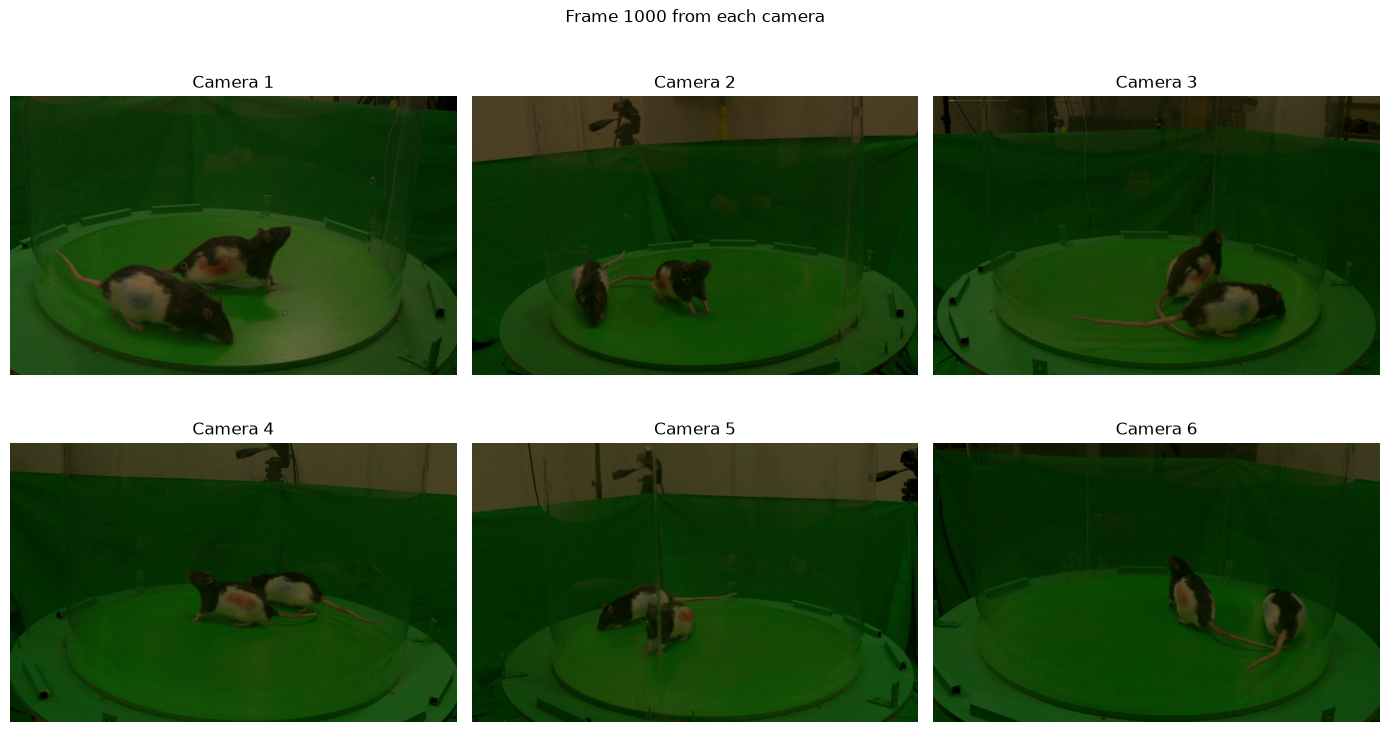

In [7]:
import cv2

if USING_LOCAL:
    session_dir = os.path.dirname(local_nwb_path)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for i, ax in enumerate(axes.flat, start=1):
        series = nwbfile.acquisition[f"VideoCamera{i}"]
        video_path = os.path.join(session_dir, series.external_file[0])

        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, 1000)  # an arbitrary frame partway through
        success, frame = cap.read()
        cap.release()

        if success:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Camera {i}")
        ax.axis("off")
    fig.suptitle("Frame 1000 from each camera")
    fig.tight_layout()
else:
    print("Skipping -- video frames require the companion .mp4 files (local read only).")


### 4b. 3D pose estimation (sDANNCE)

`PoseEstimationSDANNCE` holds one `PoseEstimationSeries` per body keypoint, each an
`(n_frames, 3)` array of (x, y, z) coordinates in millimeters, sampled at ~50 Hz.


In [8]:
pose_estimation = nwbfile.processing["behavior"]["PoseEstimationSDANNCE"]

keypoints = list(pose_estimation.pose_estimation_series.keys())
print(f"{len(keypoints)} keypoints:")
print(keypoints)


23 keypoints:
['PoseEstimationSeriesAnklel', 'PoseEstimationSeriesAnkler', 'PoseEstimationSeriesEarl', 'PoseEstimationSeriesEarr', 'PoseEstimationSeriesElbowl', 'PoseEstimationSeriesElbowr', 'PoseEstimationSeriesFootl', 'PoseEstimationSeriesFootr', 'PoseEstimationSeriesHandl', 'PoseEstimationSeriesHandr', 'PoseEstimationSeriesHipl', 'PoseEstimationSeriesHipr', 'PoseEstimationSeriesKneel', 'PoseEstimationSeriesKneer', 'PoseEstimationSeriesShoulderl', 'PoseEstimationSeriesShoulderr', 'PoseEstimationSeriesSnout', 'PoseEstimationSeriesSpinef', 'PoseEstimationSeriesSpinel', 'PoseEstimationSeriesSpinem', 'PoseEstimationSeriesTailbase', 'PoseEstimationSeriesWristl', 'PoseEstimationSeriesWristr']


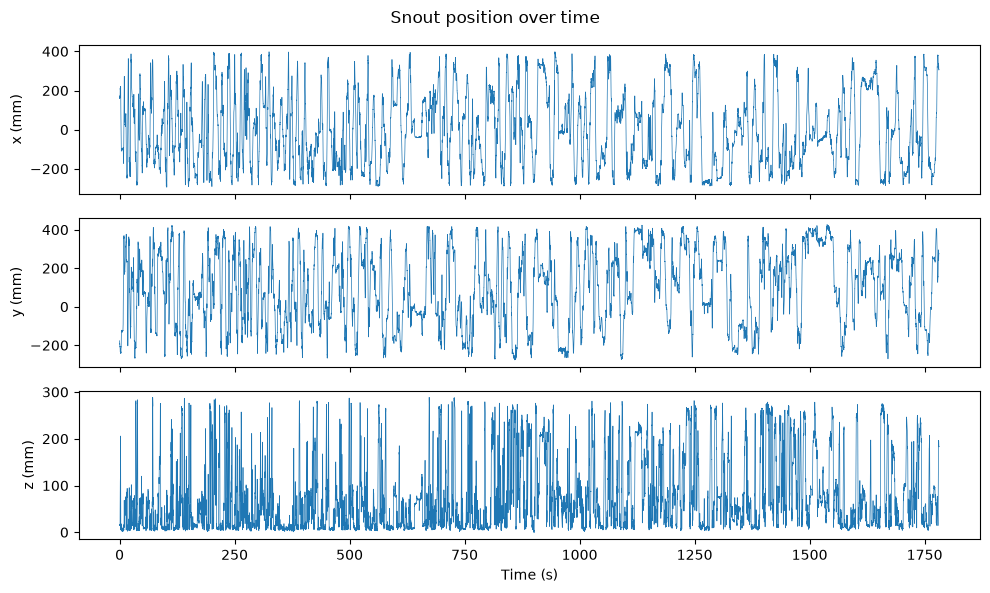

In [9]:
# XYZ trajectory of the snout over the whole session
snout = pose_estimation.pose_estimation_series["PoseEstimationSeriesSnout"]
snout_xyz = snout.data[:]
t = np.arange(snout_xyz.shape[0]) / snout.rate + snout.starting_time

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, dim, label in zip(axes, range(3), ["x", "y", "z"]):
    ax.plot(t, snout_xyz[:, dim], linewidth=0.5)
    ax.set_ylabel(f"{label} (mm)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Snout position over time")
fig.tight_layout()


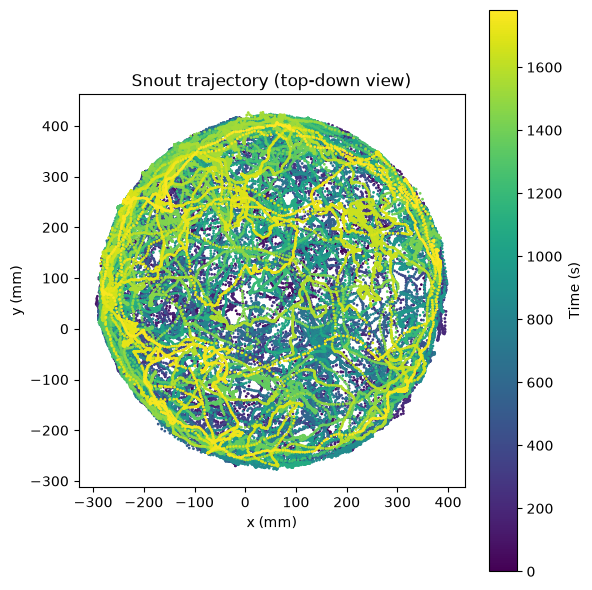

In [10]:
# Top-down (x, y) trajectory, colored by time
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(snout_xyz[:, 0], snout_xyz[:, 1], c=t, cmap="viridis", s=1)
fig.colorbar(sc, ax=ax, label="Time (s)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_aspect("equal")
ax.set_title("Snout trajectory (top-down view)")
fig.tight_layout()


### 4c. Skeleton definition + a single pose frame

`Skeletons` describes the keypoint graph (nodes + edges) used for pose estimation. We
can combine it with the per-keypoint data above to draw the full 3D pose at a single
frame.


In [11]:
skeletons = nwbfile.processing["behavior"]["Skeletons"].skeletons
skeleton = skeletons["SkeletonPoseEstimationSDANNCE_Rat1"]

nodes = skeleton.nodes[:]
edges = skeleton.edges[:]
print(f"{len(nodes)} nodes, {len(edges)} edges")
print(nodes)


23 nodes, 23 edges
['Snout' 'EarL' 'EarR' 'SpineF' 'SpineM' 'SpineL' 'TailBase' 'ShoulderL'
 'ElbowL' 'WristL' 'HandL' 'ShoulderR' 'ElbowR' 'WristR' 'HandR' 'HipL'
 'KneeL' 'AnkleL' 'FootL' 'HipR' 'KneeR' 'AnkleR' 'FootR']


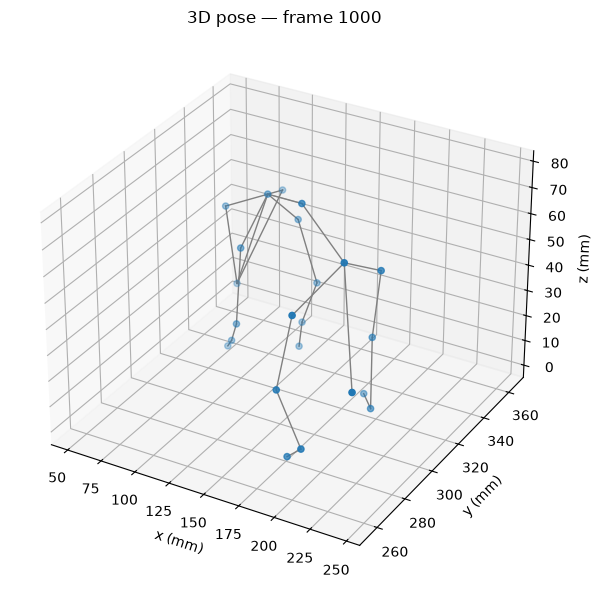

In [12]:
frame_idx = 1000

# gather (x, y, z) for every keypoint at this frame, in `nodes` order
coords = np.array(
    [pose_estimation.pose_estimation_series[f"PoseEstimationSeries{node.capitalize()}"].data[frame_idx]
     for node in nodes]
)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], color="tab:blue", s=20)
for node_i, node_j in edges:
    xs, ys, zs = coords[[node_i, node_j]].T
    ax.plot(xs, ys, zs, color="gray", linewidth=1)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("z (mm)")
ax.set_title(f"3D pose — frame {frame_idx}")
fig.tight_layout()


### 4d. Body-contact events between the two rats

`events/SkinContacts` records each moment the two rats' 3D body meshes touch, labeled
by which body parts were involved (e.g. `"right foot x left toe"`).


In [13]:
skin_contacts = nwbfile.events["SkinContacts"]
contacts_df = skin_contacts.to_dataframe()
contacts_df.head()


,timestamp,event_type,frame_index,rat1_vertex,rat2_vertex
id,,,,,
0,0.0,right finger x right foot,0,1610,185
1,0.0,right finger x right foot,0,1613,185
2,0.0,right finger x right foot,0,1614,189
3,0.0,right finger x right foot,0,1615,185
4,0.0,right finger x right foot,0,1625,189


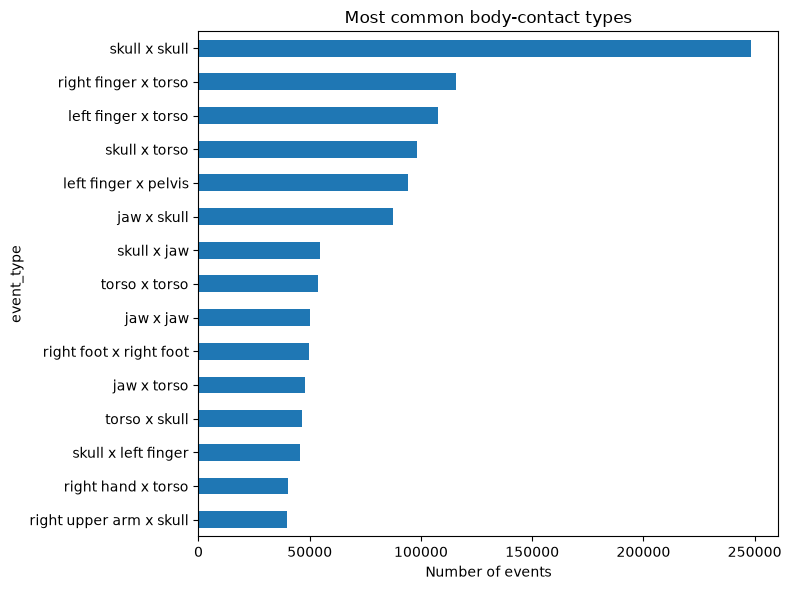

In [14]:
top_contacts = contacts_df["event_type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_contacts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of events")
ax.set_title("Most common body-contact types")
fig.tight_layout()


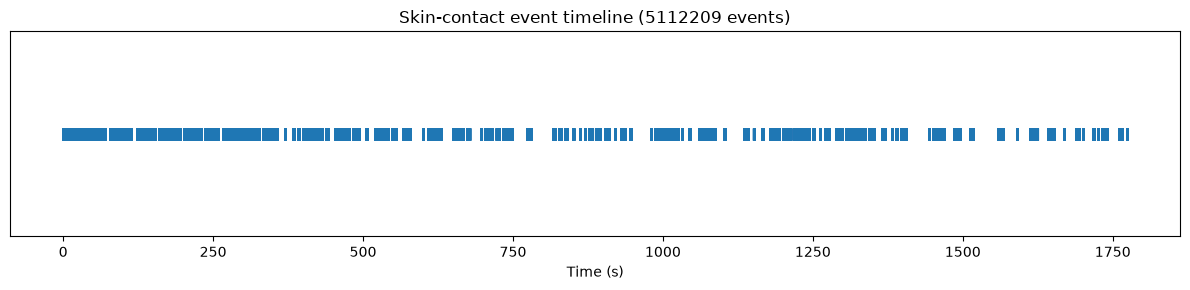

In [15]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(contacts_df["timestamp"], np.zeros(len(contacts_df)), "|", markersize=8, alpha=0.3)
ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_title(f"Skin-contact event timeline ({len(contacts_df)} events)")
fig.tight_layout()


## Summary

This notebook showed how to:

- Stream an NWB file directly from DANDI (no download) or read one from a local path
- Inspect a session's subject metadata, acquisition, processing modules, and events
- Visualize the 6-camera video acquisition (local files only)
- Plot 3D pose trajectories and a full skeleton pose from sDANNCE tracking
- Explore pairwise body-contact events between the two rats

### Further resources

- [PyNWB documentation](https://pynwb.readthedocs.io/)
- [NWB overview](https://www.nwb.org/)
- [DANDI Archive documentation](https://www.dandiarchive.org/handbook/)
- [ndx-pose extension](https://github.com/rly/ndx-pose)
- [ndx-events extension](https://github.com/rly/ndx-events)
